In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [34]:
dataset1 = pd.read_csv('/content/DL data set1 - Sheet1 (1).csv')
X = dataset1[['Input']].values
y = dataset1[['Output']].values

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=33)


In [36]:
dataset1.head()

,Input,Output
0,3,5
1,2,12
2,6,10
3,69,15
4,54,6


In [37]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [38]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [42]:
class NeuralNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(1, 8)
        self.fc2 = nn.Linear(8, 10)
        self.fc3 = nn.Linear(10, 1)

        self.relu = nn.ReLU()

        self.history = {'loss': []}

    def forward(self, x):

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [43]:
ai_brain = NeuralNet()
criterion = nn.MSELoss()
optimizer = optim.Adam(ai_brain.parameters(), lr=0.001)#lr=learning rate

In [44]:
# Name: Thrinesh Royal
# Register Number:212223230226
def train_model(ai_brain, X_train, y_train, criterion, optimizer, epochs=2000):
  for epoch in range(epochs):
        optimizer.zero_grad()
        loss = criterion(ai_brain(X_train), y_train)
        loss.backward()
        optimizer.step()

        ai_brain.history['loss'].append(loss.item())

        if epoch % 200 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}')

In [45]:
train_model(ai_brain, X_train_tensor, y_train_tensor, criterion, optimizer)


Epoch [0/2000], Loss: 352.231720
Epoch [200/2000], Loss: 287.893188
Epoch [400/2000], Loss: 151.173325
Epoch [600/2000], Loss: 128.167709
Epoch [800/2000], Loss: 121.484428
Epoch [1000/2000], Loss: 117.768524
Epoch [1200/2000], Loss: 115.655083
Epoch [1400/2000], Loss: 114.527328
Epoch [1600/2000], Loss: 114.003922
Epoch [1800/2000], Loss: 113.806168


In [46]:
with torch.no_grad():
    test_loss = criterion(ai_brain(X_test_tensor), y_test_tensor)
    print(f'Test Loss: {test_loss.item():.6f}')


Test Loss: 335.101227


In [47]:
loss_df = pd.DataFrame(ai_brain.history)

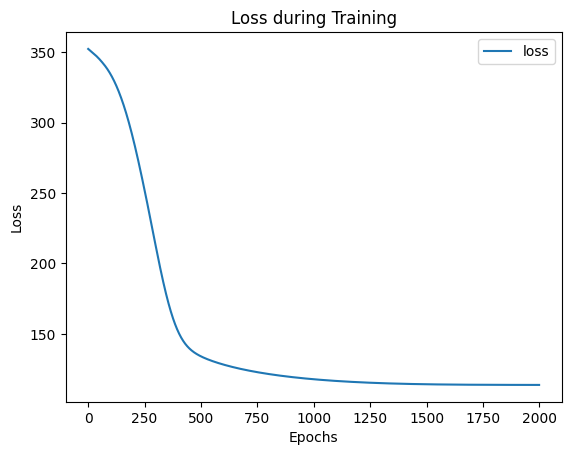

In [48]:
import matplotlib.pyplot as plt
loss_df.plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss during Training")
plt.show()

In [49]:
X_n1_1 = torch.tensor([[9]], dtype=torch.float32)
prediction = ai_brain(torch.tensor(scaler.transform(X_n1_1), dtype=torch.float32)).item()
print(f'Prediction: {prediction}')

Prediction: 16.15253448486328
